In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pickle
import scienceplots

plt.style.use(['science','notebook','light'])
colors = ["#00BBF9", "#CC2836", "#F3A712","#3eb690","#A05496","#114b5f"]
markers = ['o-','s-','^-']

### Lorenz 96, all coords

In [15]:
epsilons = np.linspace(0.,1.5,31)
alphas = np.linspace(0.,1.5,50)

info_imbalances_X_to_Y, info_imbalances_Y_to_X = pickle.load(open(f"../fig3_errors/analysis/ig_allcoords/pickles/lorenz96/seed0.p","rb"))
print(info_imbalances_X_to_Y.shape, info_imbalances_Y_to_X.shape)

(31, 50) (31, 50)


Text(0, 0.5, 'Imbalance Gain [%]')

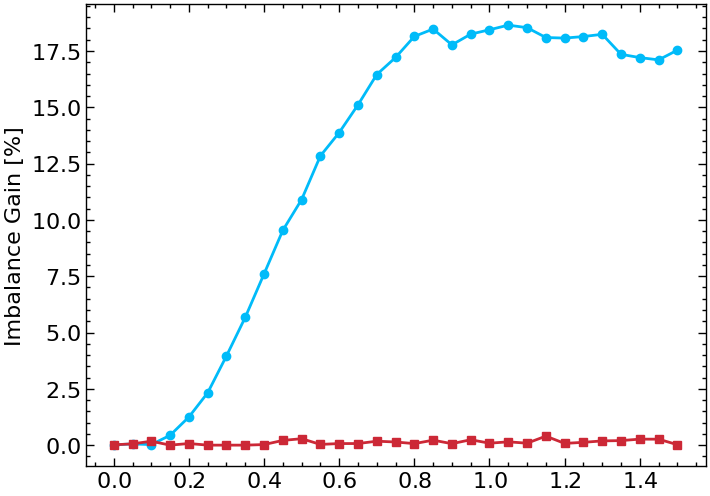

In [16]:
IGs_X_to_Y = 100*(info_imbalances_X_to_Y[:,0,np.newaxis]-np.min(info_imbalances_X_to_Y,axis=-1,keepdims=True)) \
    / info_imbalances_X_to_Y[:,0,np.newaxis]
IGs_Y_to_X = 100*(info_imbalances_Y_to_X[:,0,np.newaxis]-np.min(info_imbalances_Y_to_X,axis=-1,keepdims=True)) \
    / info_imbalances_Y_to_X[:,0,np.newaxis]

plt.plot()
plt.plot(epsilons, IGs_X_to_Y, markers[0], color=colors[0], label="$X\\rightarrow Y$")
plt.plot(epsilons, IGs_Y_to_X, markers[1], color=colors[1], label="$Y\\rightarrow X$")
plt.ylabel("Imbalance Gain [%]")

In [17]:
info_imbalances_X_to_Y_null = np.zeros((1000,len(epsilons),len(alphas)))
info_imbalances_Y_to_X_null = np.zeros((1000,len(epsilons),len(alphas))) 

for seed in range(1000):
    info_imbalances_X_to_Y_null[seed], info_imbalances_Y_to_X_null[seed] = pickle.load(open(f"./ig_allcoords/pickles/lorenz96/seed{seed}.p","rb"))
print(info_imbalances_X_to_Y_null.shape, info_imbalances_Y_to_X_null.shape)

IGs_X_to_Y_null = 100*(info_imbalances_X_to_Y_null[:,:,0,np.newaxis]-np.min(info_imbalances_X_to_Y_null,axis=-1,keepdims=True)) \
    / info_imbalances_X_to_Y_null[:,:,0,np.newaxis]
IGs_Y_to_X_null = 100*(info_imbalances_Y_to_X_null[:,:,0,np.newaxis]-np.min(info_imbalances_Y_to_X_null,axis=-1,keepdims=True)) \
    / info_imbalances_Y_to_X_null[:,:,0,np.newaxis]
print(IGs_X_to_Y_null.shape, IGs_Y_to_X_null.shape)


(1000, 31, 50) (1000, 31, 50)
(1000, 31, 1) (1000, 31, 1)


In [18]:
n_tpd = 0 # number of true positive detections
n_fpd = 0 # number of false positive detections

for ieps, eps in enumerate(epsilons):
    counts_XtoY, bins_XtoY = np.histogram(IGs_X_to_Y_null[:,ieps], bins=15, density=True)
    counts_YtoX, bins_YtoX = np.histogram(IGs_Y_to_X_null[:,ieps], bins=15, density=True)

    #plt.figure(figsize=(6,4))
    ##plt.stairs(counts_XtoY, bins_XtoY, label="$X\\rightarrow Y$, null distribution", linewidth=2)
    #plt.hist(IGs_X_to_Y_null[:,ieps], bins=15, alpha=0.5, density=True, ec="k", histtype='stepfilled', label="$p_{H_0}\, (X\\rightarrow Y)$")
    #plt.vlines(IGs_X_to_Y[ieps], 0., max(np.append(counts_XtoY,counts_YtoX)), color="black", linestyle="--", label="Measured $(X\\rightarrow Y)$")
    #plt.title(f"eps = {eps:.2f}")
#
    ##plt.stairs(counts_YtoX, bins_YtoX, label="$Y\\rightarrow X$, null distribution", linewidth=2)
    #plt.hist(IGs_Y_to_X_null[:,ieps], bins=15, alpha=0.5, density=True, ec="k", histtype='stepfilled', label="$p_{H_0}\, (Y\\rightarrow X)$")
    #plt.vlines(IGs_Y_to_X[ieps], 0., max(np.append(counts_XtoY,counts_YtoX)), color="red", linestyle="--", label="Measured $(Y\\rightarrow X)$")
    #plt.title(f"eps = {eps:.2f}")
#
    #plt.yscale("log")
    #plt.xlabel("Imbalance Gain [%]")
    #plt.ylabel("Probability density")
    #plt.legend(loc="upper center")
    #plt.savefig(f"./figures/ieps{ieps}.pdf", dpi=300)
    #plt.show()

    n_points_tail = (IGs_X_to_Y[ieps] < IGs_X_to_Y_null[:,ieps]).sum()
    n_tpd += (n_points_tail <= 1)

    n_points_tail = (IGs_Y_to_X[ieps] < IGs_Y_to_X_null[:,ieps]).sum()
    n_fpd += (n_points_tail <= 1)

print(f"True positive detections: {n_tpd}/{len(epsilons)} ({100*n_tpd/len(epsilons):.2f}%)")
print(f"False positive detections: {n_fpd}/{len(epsilons)} ({100*n_fpd/len(epsilons):.2f}%)")

True positive detections: 28/31 (90.32%)
False positive detections: 3/31 (9.68%)


### ROC curve

In [9]:
n_tpd = np.zeros(1000)
n_fpd = np.zeros(1000)

for p in range(1000):
    for ieps, eps in enumerate(epsilons):
        n_points_tail_XtoY = (IGs_X_to_Y[ieps] < IGs_X_to_Y_null[:,ieps]).sum()
        n_points_tail_YtoX = (IGs_Y_to_X[ieps] < IGs_Y_to_X_null[:,ieps]).sum()

        n_tpd[p] += (n_points_tail_XtoY < p)
        n_fpd[p] += (n_points_tail_YtoX < p)

Text(0, 0.5, 'True positive rate')

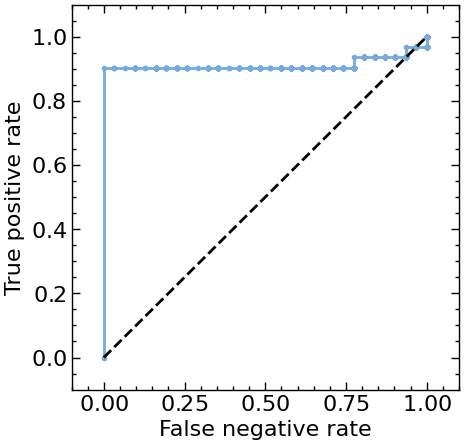

In [10]:
plt.figure(figsize=(5,5))
plt.plot(n_fpd/31, n_tpd/31, '.-')
plt.plot(np.linspace(0,1,2),np.linspace(0,1,2),'--',color="black")
plt.xlim([-0.1,1.1])
plt.ylim([-0.1,1.1])
plt.xlabel("False negative rate")
plt.ylabel("True positive rate")

### Lorenz 96, embeddings

In [11]:
epsilons = np.linspace(0.,1.5,31)
alphas = np.linspace(0.,1.5,50)

info_imbalances_X_to_Y, info_imbalances_Y_to_X = pickle.load(open(f"../fig3_errors/analysis/ig_embeddings/pickles/lorenz96/seed0.p","rb"))
print(info_imbalances_X_to_Y.shape, info_imbalances_Y_to_X.shape)

(31, 50) (31, 50)


Text(0, 0.5, 'Imbalance Gain [%]')

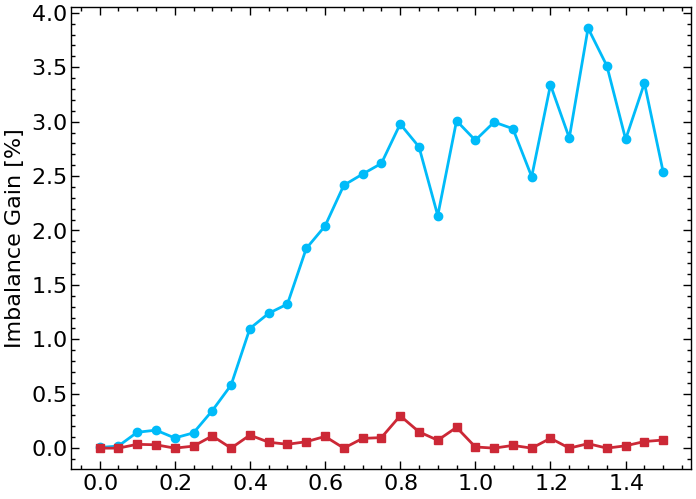

In [12]:
IGs_X_to_Y = 100*(info_imbalances_X_to_Y[:,0,np.newaxis]-np.min(info_imbalances_X_to_Y,axis=-1,keepdims=True)) \
    / info_imbalances_X_to_Y[:,0,np.newaxis]
IGs_Y_to_X = 100*(info_imbalances_Y_to_X[:,0,np.newaxis]-np.min(info_imbalances_Y_to_X,axis=-1,keepdims=True)) \
    / info_imbalances_Y_to_X[:,0,np.newaxis]

plt.plot()
plt.plot(epsilons, IGs_X_to_Y, markers[0], color=colors[0], label="$X\\rightarrow Y$")
plt.plot(epsilons, IGs_Y_to_X, markers[1], color=colors[1], label="$Y\\rightarrow X$")
plt.ylabel("Imbalance Gain [%]")

In [13]:
info_imbalances_X_to_Y_null = np.zeros((1000,len(epsilons),len(alphas)))
info_imbalances_Y_to_X_null = np.zeros((1000,len(epsilons),len(alphas))) 

for seed in range(1000):
    info_imbalances_X_to_Y_null[seed], info_imbalances_Y_to_X_null[seed] = pickle.load(open(f"./ig_embeddings/pickles/lorenz96/seed{seed}.p","rb"))
print(info_imbalances_X_to_Y_null.shape, info_imbalances_Y_to_X_null.shape)

IGs_X_to_Y_null = 100*(info_imbalances_X_to_Y_null[:,:,0,np.newaxis]-np.min(info_imbalances_X_to_Y_null,axis=-1,keepdims=True)) \
    / info_imbalances_X_to_Y_null[:,:,0,np.newaxis]
IGs_Y_to_X_null = 100*(info_imbalances_Y_to_X_null[:,:,0,np.newaxis]-np.min(info_imbalances_Y_to_X_null,axis=-1,keepdims=True)) \
    / info_imbalances_Y_to_X_null[:,:,0,np.newaxis]
print(IGs_X_to_Y_null.shape, IGs_Y_to_X_null.shape)


(1000, 31, 50) (1000, 31, 50)
(1000, 31, 1) (1000, 31, 1)


In [14]:
n_tpd = 0 # number of true positive detections
n_fpd = 0 # number of false positive detections

for ieps, eps in enumerate(epsilons):
    counts_XtoY, bins_XtoY = np.histogram(IGs_X_to_Y_null[:,ieps], bins=20, density=True)
    counts_YtoX, bins_YtoX = np.histogram(IGs_Y_to_X_null[:,ieps], bins=20, density=True)
    
    #plt.stairs(counts_XtoY, bins_XtoY, label="X->Y, null distribution")
    ##plt.hist(IGs_X_to_Y_null[:,ieps], bins=100, alpha=0.5)
    #plt.vlines(IGs_X_to_Y[ieps], 0., max(np.append(counts_XtoY,counts_YtoX)), color="black", linestyle="--", label="X->Y, measured")
    #plt.title(f"eps = {eps:.2f}")
#
    #plt.stairs(counts_YtoX, bins_YtoX, label="Y->X, null distribution")
    ##plt.hist(IGs_Y_to_X_null[:,ieps], bins=100, alpha=0.5)
    #plt.vlines(IGs_Y_to_X[ieps], 0., max(np.append(counts_XtoY,counts_YtoX)), color="red", linestyle="--", label="Y->X, measured")
    #plt.title(f"eps = {eps:.2f}")
#
    #plt.yscale("log")
    #plt.legend()
    #plt.show()

    n_points_tail = (IGs_X_to_Y[ieps] < IGs_X_to_Y_null[:,ieps]).sum()
    n_tpd += (n_points_tail <= 1)

    n_points_tail = (IGs_Y_to_X[ieps] < IGs_Y_to_X_null[:,ieps]).sum()
    n_fpd += (n_points_tail <= 1)

print(f"True positive detections: {n_tpd}/{len(epsilons)} ({100*n_tpd/len(epsilons):.2f}%)")
print(f"False positive detections: {n_fpd}/{len(epsilons)} ({100*n_fpd/len(epsilons):.2f}%)")

True positive detections: 25/31 (80.65%)
False positive detections: 0/31 (0.00%)


### ROC curve

In [13]:
n_tpd = np.zeros(1000)
n_fpd = np.zeros(1000)

for p in range(1000):
    for ieps, eps in enumerate(epsilons):
        n_points_tail_XtoY = (IGs_X_to_Y[ieps] < IGs_X_to_Y_null[:,ieps]).sum()
        n_points_tail_YtoX = (IGs_Y_to_X[ieps] < IGs_Y_to_X_null[:,ieps]).sum()

        n_tpd[p] += (n_points_tail_XtoY < p)
        n_fpd[p] += (n_points_tail_YtoX < p)

Text(0, 0.5, 'True positive rate')

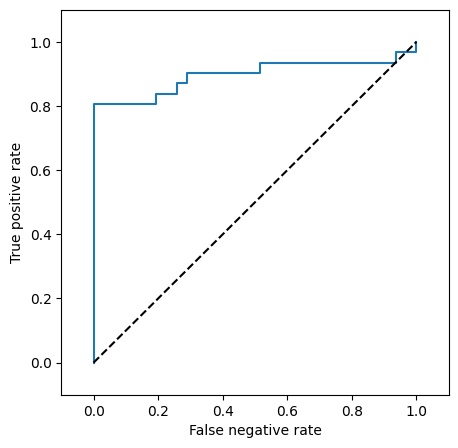

In [15]:
plt.figure(figsize=(5,5))
plt.plot(n_fpd/31, n_tpd/31, '-')
plt.plot(np.linspace(0,1,2),np.linspace(0,1,2),'--',color="black")
plt.xlim([-0.1,1.1])
plt.ylim([-0.1,1.1])
plt.xlabel("False negative rate")
plt.ylabel("True positive rate")